<a href="https://colab.research.google.com/github/Young-yrx/guizhou-landslide/blob/main/guizhou.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

XGBoost

In [41]:
# -*- coding: utf-8 -*-
"""
贵州水城滑坡易发性评价 —— 逻辑回归、XGBoost、随机森林对比（K折交叉验证版）
特征列表（共11个）：
    地形因子：Curvatu_ASTG1, Aspect_ASTGT1, Slope_ASTGTM1, Reclass_ASTG1, PTC, TWI
    降雨因子：rain20190716, rain20190720, rain20190721, rain20190722, rain20190723
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import (accuracy_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve, auc,
                             precision_score, recall_score, f1_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
import xgboost as xgb
import rasterio
import warnings
warnings.filterwarnings('ignore')

In [42]:
# =============================================================================
# 1. 读取数据并定义特征列
# =============================================================================
df_landslide = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/date/landslide.xls', sheet_name='landslide')
df_non = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/date/non_landslide.xls', sheet_name='non_landslide')

# 定义11个特征列名（请确保两个文件中的列名完全一致）
feature_cols = [
    'Curvatu_ASTG1',      # 曲率
    'Aspect_ASTGT1',      # 坡向
    'Slope_ASTGTM1',      # 坡度
    'Reclass_ASTG1',      # 重分类（岩性/地层）
    'PTC',                # PTC（剖面曲率或其它）
    'TWI',                # 地形湿度指数
    'rain20190716',       # 降雨量 2019-07-16
    'rain20190720',       # 降雨量 2019-07-20
    'rain20190721',       # 降雨量 2019-07-21
    'rain20190722',       # 降雨量 2019-07-22
    'rain20190723'        # 降雨量 2019-07-23
]

# 提取特征和标签
X_landslide = df_landslide[feature_cols].copy()
y_landslide = np.ones(len(X_landslide))  # 滑坡标签 = 1

X_non = df_non[feature_cols].copy()
y_non = np.zeros(len(X_non))             # 非滑坡标签 = 0

# 合并数据
X = pd.concat([X_landslide, X_non], axis=0, ignore_index=True)
y = np.concatenate([y_landslide, y_non])

print(f"总样本数: {len(X)}，滑坡样本: {int(y.sum())}，非滑坡样本: {len(y) - int(y.sum())}")
print(f"特征列名: {X.columns.tolist()}")


总样本数: 2400，滑坡样本: 1200，非滑坡样本: 1200
特征列名: ['Curvatu_ASTG1', 'Aspect_ASTGT1', 'Slope_ASTGTM1', 'Reclass_ASTG1', 'PTC', 'TWI', 'rain20190716', 'rain20190720', 'rain20190721', 'rain20190722', 'rain20190723']


In [43]:
# =============================================================================
# 2. 处理缺失值（填充中位数）
# =============================================================================
imputer = SimpleImputer(strategy='median')
X = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)
print("缺失值已使用中位数填充。")

缺失值已使用中位数填充。


In [44]:
# =============================================================================
# 3. 划分训练集与测试集（用于最终独立测试）
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"训练集: {len(X_train)}，测试集: {len(X_test)}")

训练集: 1920，测试集: 480


In [45]:
# =============================================================================
# 4. 定义三个模型
# =============================================================================
def get_models():
    """返回三个模型的字典"""
    models = {}

    # 逻辑回归（带标准化）
    lr_pipeline = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            solver='liblinear',
            random_state=42
        )
    )
    models['Logistic Regression'] = lr_pipeline

    # XGBoost
    scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])
    xgb_model = xgb.XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss'
    )
    models['XGBoost'] = xgb_model

    # 随机森林
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    models['Random Forest'] = rf_model

    return models

models = get_models()

In [46]:
# =============================================================================
# 5. K 折交叉验证评估（K=5）
# =============================================================================
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 存储每个模型的交叉验证结果
cv_results = {}

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"正在对 {name} 进行 5 折交叉验证...")
    print('='*60)

    # 交叉验证预测概率（用于计算AUC和绘制ROC）
    y_proba_cv = cross_val_predict(model, X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    y_pred_cv = (y_proba_cv > 0.5).astype(int)

    # 计算各项指标
    acc_cv = accuracy_score(y_train, y_pred_cv)
    prec_cv = precision_score(y_train, y_pred_cv)
    rec_cv = recall_score(y_train, y_pred_cv)
    f1_cv = f1_score(y_train, y_pred_cv)
    auc_cv = roc_auc_score(y_train, y_proba_cv)

    # 计算各折的AUC以评估稳定性
    auc_scores = cross_val_score(model, X_train, y_train, cv=kfold, scoring='roc_auc')

    cv_results[name] = {
        'Accuracy': acc_cv,
        'Precision': prec_cv,
        'Recall': rec_cv,
        'F1-score': f1_cv,
        'AUC': auc_cv,
        'AUC_per_fold': auc_scores,
        'AUC_mean': auc_scores.mean(),
        'AUC_std': auc_scores.std()
    }

    print(f"交叉验证结果（训练集，K=5）:")
    print(f"  Accuracy : {acc_cv:.4f}")
    print(f"  Precision: {prec_cv:.4f}")
    print(f"  Recall   : {rec_cv:.4f}")
    print(f"  F1-score : {f1_cv:.4f}")
    print(f"  AUC      : {auc_cv:.4f} (各折: {np.round(auc_scores, 4)})")
    print(f"  AUC Mean ± Std: {auc_scores.mean():.4f} ± {auc_scores.std():.4f}")


正在对 Logistic Regression 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.9297
  Precision: 0.9096
  Recall   : 0.9542
  F1-score : 0.9314
  AUC      : 0.9688 (各折: [0.969  0.9608 0.9613 0.9736 0.9771])
  AUC Mean ± Std: 0.9684 ± 0.0065

正在对 XGBoost 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.9849
  Precision: 0.9707
  Recall   : 1.0000
  F1-score : 0.9851
  AUC      : 0.9977 (各折: [0.9979 0.9992 0.9954 0.9993 0.997 ])
  AUC Mean ± Std: 0.9978 ± 0.0015

正在对 Random Forest 进行 5 折交叉验证...
交叉验证结果（训练集，K=5）:
  Accuracy : 0.9828
  Precision: 0.9668
  Recall   : 1.0000
  F1-score : 0.9831
  AUC      : 0.9988 (各折: [0.999  0.9997 0.9996 0.9986 0.9975])
  AUC Mean ± Std: 0.9989 ± 0.0008


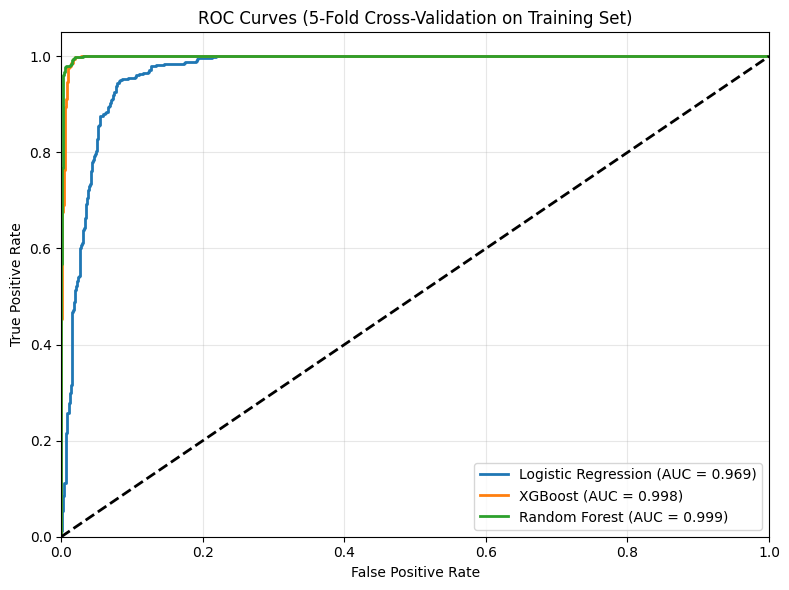

In [47]:
# =============================================================================
# 6. 交叉验证 ROC 曲线对比（基于训练集CV预测概率）
# =============================================================================
plt.figure(figsize=(8, 6))
for name in models.keys():
    y_proba = cross_val_predict(models[name], X_train, y_train, cv=kfold, method='predict_proba')[:, 1]
    fpr, tpr, _ = roc_curve(y_train, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (5-Fold Cross-Validation on Training Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

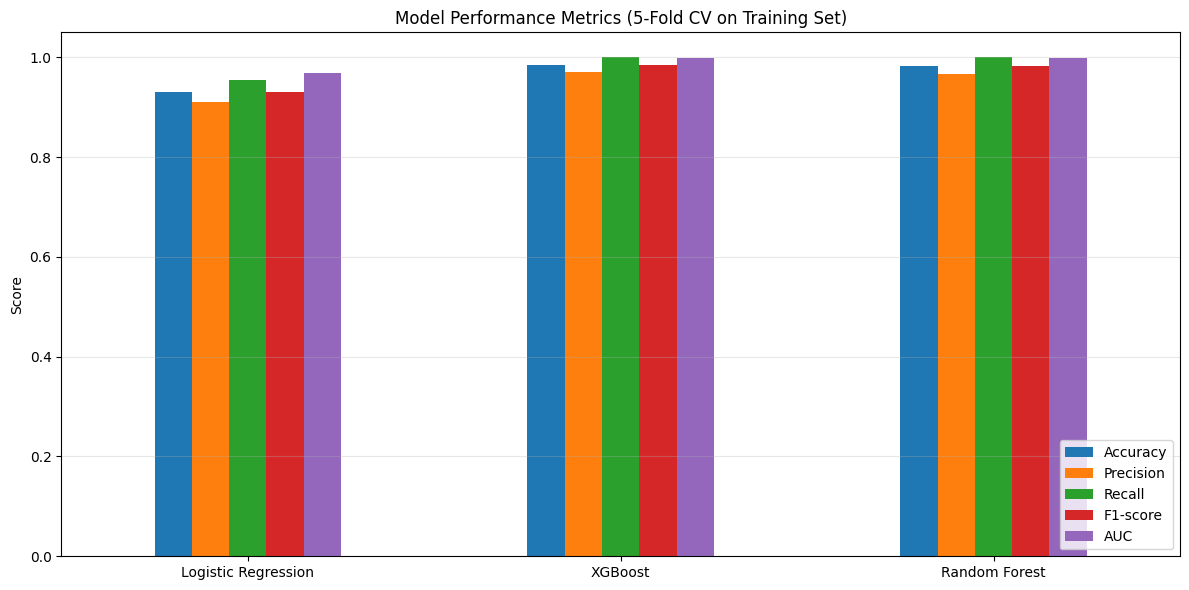


模型性能对比表（K=5交叉验证）
                     Accuracy Precision    Recall  F1-score       AUC
Logistic Regression  0.929688  0.909633  0.954167  0.931368  0.968817
XGBoost              0.984896  0.970677       1.0  0.985121  0.997666
Random Forest        0.982812  0.966767       1.0  0.983103  0.998822


In [48]:
# =============================================================================
# 7. 交叉验证指标汇总条形图
# =============================================================================
metrics_df = pd.DataFrame(cv_results).T[['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC']]
metrics_df.plot(kind='bar', figsize=(12, 6))
plt.title('Model Performance Metrics (5-Fold CV on Training Set)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 打印详细对比表
print("\n" + "="*60)
print("模型性能对比表（K=5交叉验证）")
print("="*60)
print(metrics_df.to_string())


In [49]:
# =============================================================================
# 8. 使用全部训练数据训练最终模型，并在独立测试集上评估
# =============================================================================
print("\n" + "="*60)
print("在全部训练数据上重新训练模型，并在独立测试集上评估...")
print("="*60)

final_models = {}
test_results = {}
test_probs = {}  # 保存测试集预测概率用于诊断图

for name, model in models.items():
    # 在完整训练集上训练
    model.fit(X_train, y_train)
    final_models[name] = model

    # 在测试集上评估
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    test_probs[name] = y_prob

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_prob)

    test_results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-score': f1,
        'AUC': auc_score
    }

    print(f"\n{name} 在独立测试集上的表现:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-score : {f1:.4f}")
    print(f"  AUC      : {auc_score:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Non-landslide', 'Landslide']))


在全部训练数据上重新训练模型，并在独立测试集上评估...

Logistic Regression 在独立测试集上的表现:
  Accuracy : 0.9021
  Precision: 0.8755
  Recall   : 0.9375
  F1-score : 0.9054
  AUC      : 0.9657
               precision    recall  f1-score   support

Non-landslide       0.93      0.87      0.90       240
    Landslide       0.88      0.94      0.91       240

     accuracy                           0.90       480
    macro avg       0.90      0.90      0.90       480
 weighted avg       0.90      0.90      0.90       480


XGBoost 在独立测试集上的表现:
  Accuracy : 0.9688
  Precision: 0.9412
  Recall   : 1.0000
  F1-score : 0.9697
  AUC      : 0.9975
               precision    recall  f1-score   support

Non-landslide       1.00      0.94      0.97       240
    Landslide       0.94      1.00      0.97       240

     accuracy                           0.97       480
    macro avg       0.97      0.97      0.97       480
 weighted avg       0.97      0.97      0.97       480


Random Forest 在独立测试集上的表现:
  Accuracy : 0.9729
  P

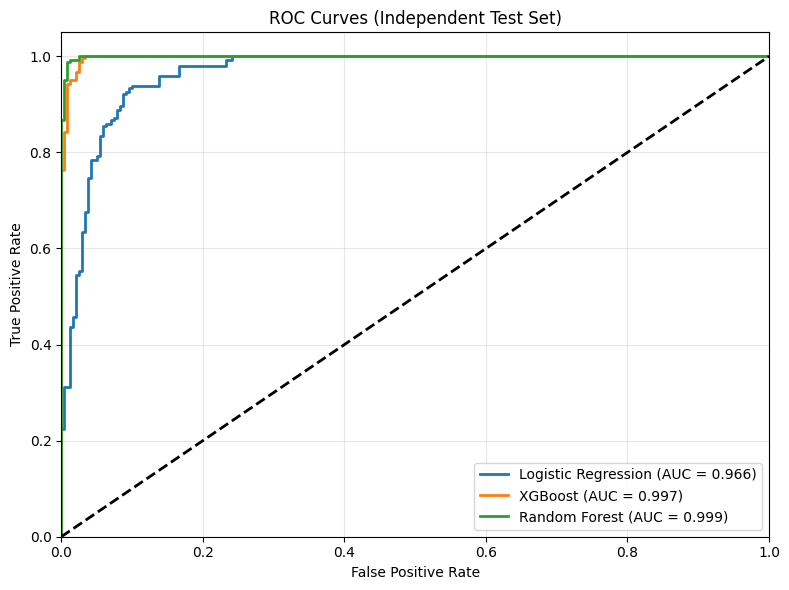

In [50]:
# =============================================================================
# 9. 独立测试集 ROC 曲线对比
# =============================================================================
plt.figure(figsize=(8, 6))
for name, model in final_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Independent Test Set)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

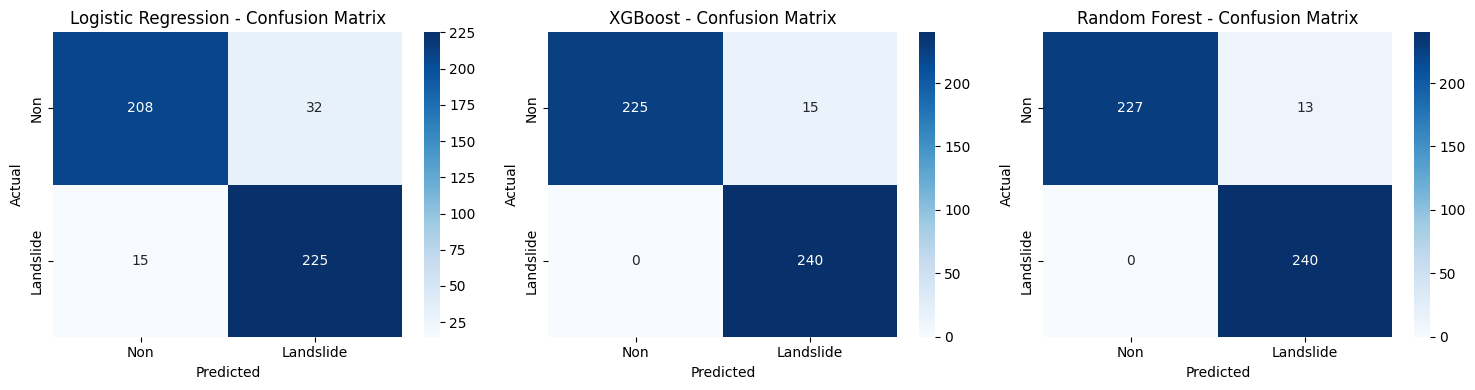

In [51]:
# =============================================================================
# 10. 混淆矩阵对比（测试集）
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, model) in enumerate(final_models.items()):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Non', 'Landslide'],
                yticklabels=['Non', 'Landslide'], ax=axes[idx])
    axes[idx].set_title(f'{name} - Confusion Matrix')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
plt.tight_layout()
plt.show()

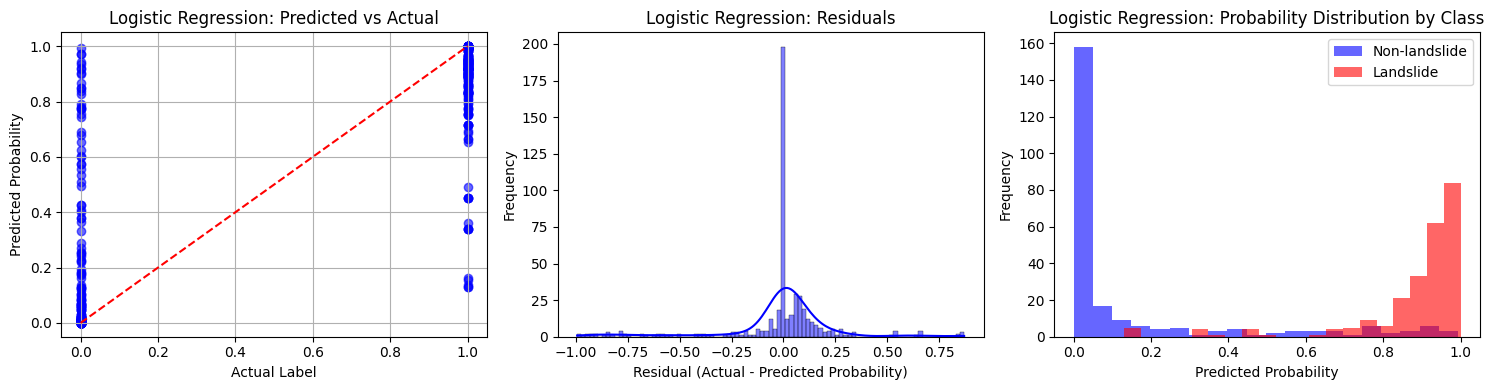

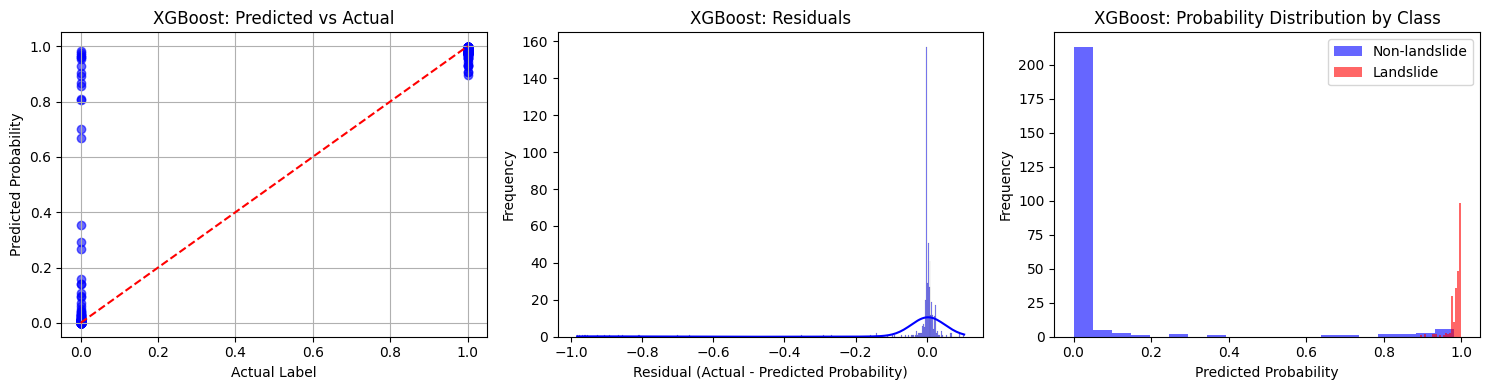

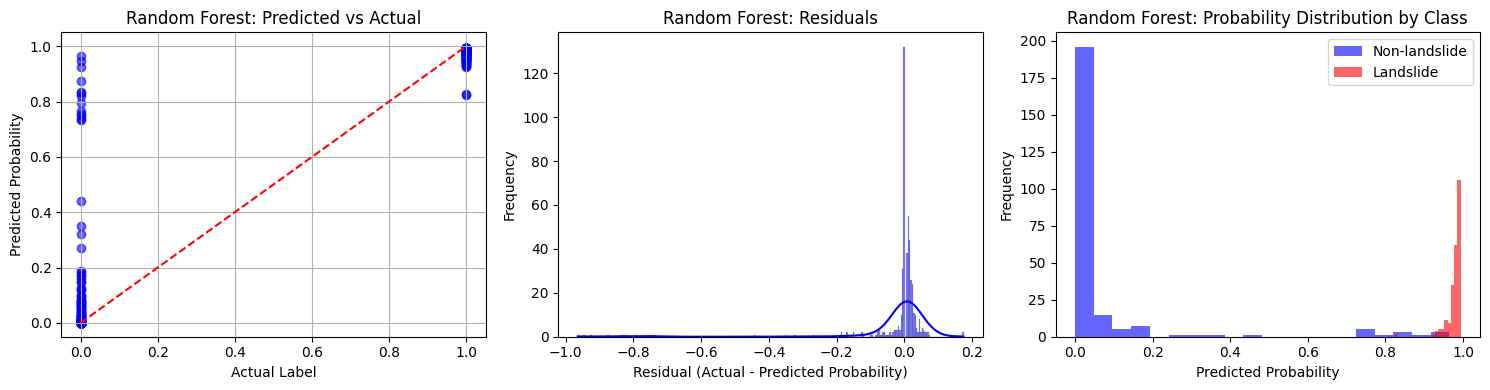

In [52]:
# =============================================================================
# 11. 诊断子图（预测概率 vs 真实标签、残差分布、概率分布）—— 为每个模型单独绘制
# =============================================================================
for name in final_models.keys():
    y_prob = test_probs[name]
    residual = y_test - y_prob

    # 分离滑坡/非滑坡概率
    probs_landslide = y_prob[y_test == 1]
    probs_non = y_prob[y_test == 0]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # 子图1：预测概率 vs 真实标签散点图
    axes[0].scatter(y_test, y_prob, alpha=0.6, color='blue')
    axes[0].plot([0, 1], [0, 1], 'r--')
    axes[0].set_xlabel('Actual Label')
    axes[0].set_ylabel('Predicted Probability')
    axes[0].set_title(f'{name}: Predicted vs Actual')
    axes[0].grid(True)

    # 子图2：残差分布直方图
    sns.histplot(residual, kde=True, color='blue', ax=axes[1])
    axes[1].set_title(f'{name}: Residuals')
    axes[1].set_xlabel('Residual (Actual - Predicted Probability)')
    axes[1].set_ylabel('Frequency')

    # 子图3：预测概率分布（分滑坡/非滑坡）
    axes[2].hist(probs_non, bins=20, alpha=0.6, label='Non-landslide', color='blue')
    axes[2].hist(probs_landslide, bins=20, alpha=0.6, label='Landslide', color='red')
    axes[2].set_xlabel('Predicted Probability')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'{name}: Probability Distribution by Class')
    axes[2].legend()

    plt.tight_layout()
    plt.show()


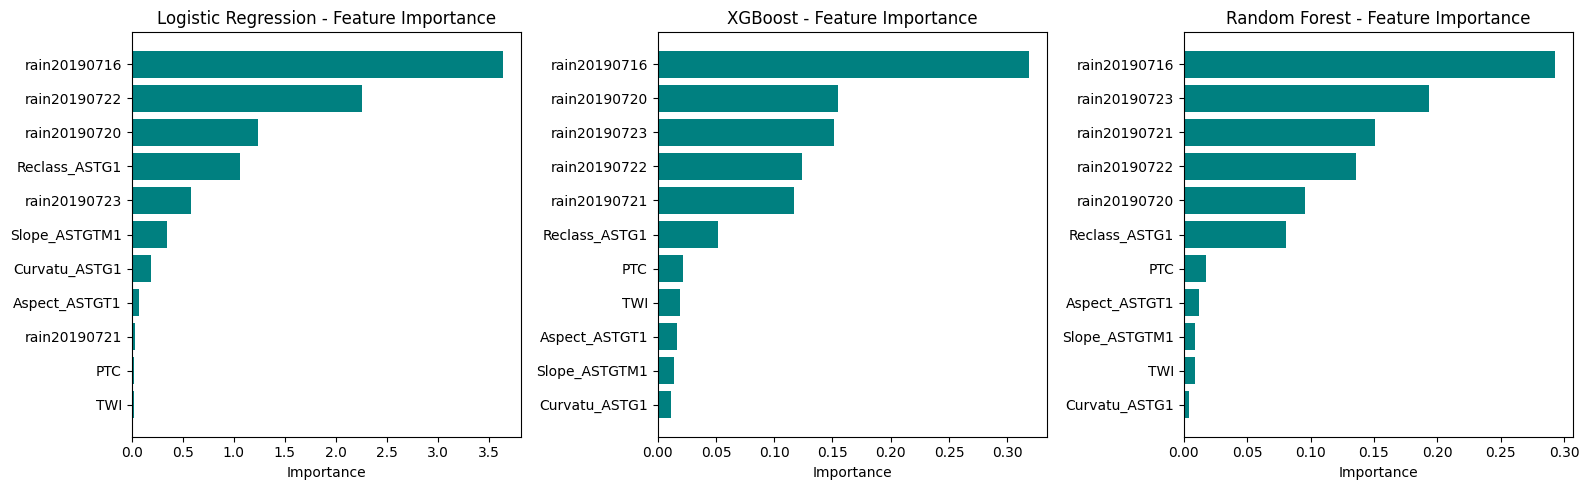

In [53]:
# =============================================================================
# 12. 特征重要性对比
# =============================================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for idx, (name, model) in enumerate(final_models.items()):
    if name == 'Logistic Regression':
        coef = model.named_steps['logisticregression'].coef_[0]
        importance = np.abs(coef)
    else:
        importance = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_cols, 'Importance': importance})
    fi_df = fi_df.sort_values('Importance', ascending=True)
    axes[idx].barh(fi_df['Feature'], fi_df['Importance'], color='teal')
    axes[idx].set_title(f'{name} - Feature Importance')
    axes[idx].set_xlabel('Importance')
plt.tight_layout()
plt.show()


总像素数: 12967201，有效像素数: 6676231
正在使用 Logistic Regression 进行栅格预测...
  已保存至: landslide_susceptibility_Logistic_Regression.tif
正在使用 XGBoost 进行栅格预测...
  已保存至: landslide_susceptibility_XGBoost.tif
正在使用 Random Forest 进行栅格预测...
  已保存至: landslide_susceptibility_Random_Forest.tif


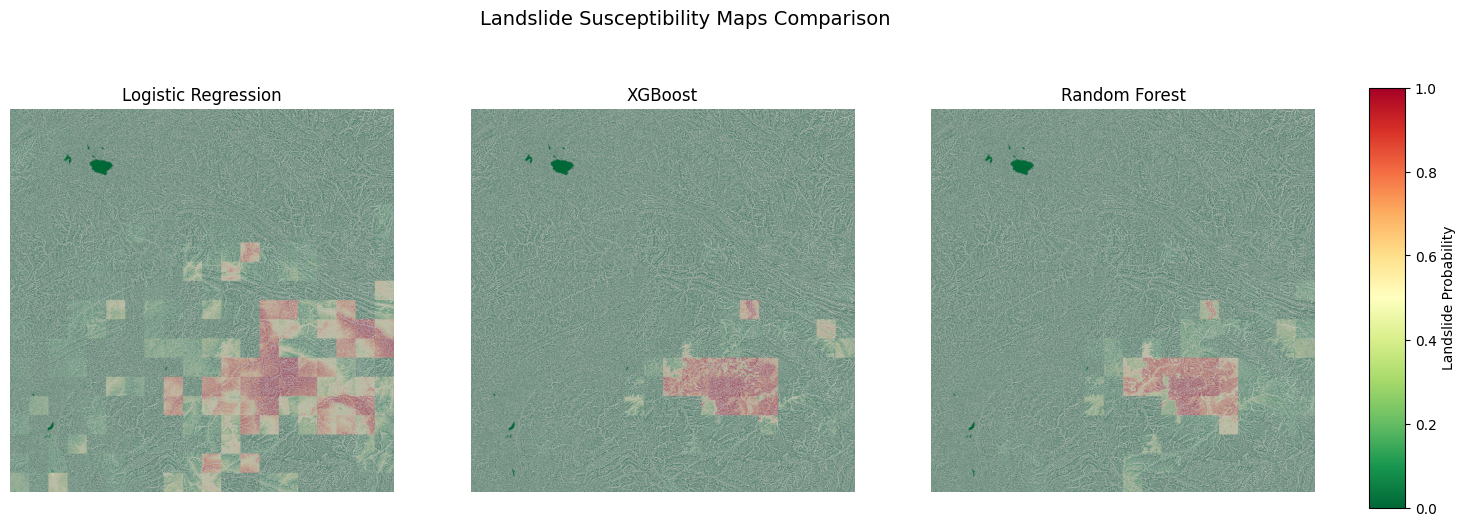


✅ 所有分析完成！


In [54]:
# =============================================================================
# 13. 研究区栅格预测（需准备11个栅格文件）
# =============================================================================
raster_files = [
    '/content/drive/MyDrive/Colab Notebooks/date/Curvatu_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Aspect_ASTGT1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Slope_ASTGTM1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/Reclass_ASTG1.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/PTC.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/TWI.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190716.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190720.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190721.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190722.tif',
    '/content/drive/MyDrive/Colab Notebooks/date/rain20190723.tif'
]

if len(raster_files) != len(feature_cols):
    raise ValueError(f"栅格文件数量 ({len(raster_files)}) 与特征数量 ({len(feature_cols)}) 不一致！")

with rasterio.open(raster_files[0]) as src:
    profile = src.profile
    ref_shape = (src.height, src.width)
    transform = src.transform
    crs = src.crs

feature_stack = np.zeros((ref_shape[0], ref_shape[1], len(raster_files)), dtype=np.float32)
for i, fpath in enumerate(raster_files):
    with rasterio.open(fpath) as src:
        shape = (src.height, src.width)
        if shape != ref_shape:
            raise ValueError(f"栅格尺寸不一致！参考: {raster_files[0]} 尺寸: {ref_shape}, 当前: {fpath} 尺寸: {shape}")
        feature_stack[:, :, i] = src.read(1)

feature_stack[feature_stack < -9990] = np.nan
rows, cols, bands = feature_stack.shape
feature_2d = feature_stack.reshape(-1, bands)
valid_mask = ~np.isnan(feature_2d).any(axis=1)
valid_features = feature_2d[valid_mask]

if valid_features.shape[0] > 0:
    valid_features = imputer.transform(valid_features)
else:
    raise ValueError("没有有效像素。")

print(f"总像素数: {rows*cols}，有效像素数: {valid_features.shape[0]}")

prob_maps = {}
for name, model in final_models.items():
    print(f"正在使用 {name} 进行栅格预测...")
    pred_prob = model.predict_proba(valid_features)[:, 1]
    prob_map = np.full(rows * cols, np.nan, dtype=np.float32)
    prob_map[valid_mask] = pred_prob
    prob_map = prob_map.reshape(rows, cols)
    prob_maps[name] = prob_map

    output_file = f'landslide_susceptibility_{name.replace(" ", "_")}.tif'
    out_profile = profile.copy()
    out_profile.update(dtype=rasterio.float32, count=1, compress='lzw', nodata=np.nan)
    with rasterio.open(output_file, 'w', **out_profile) as dst:
        dst.write(prob_map, 1)
    print(f"  已保存至: {output_file}")

# 绘制三模型易发性图对比
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for idx, (name, prob_map) in enumerate(prob_maps.items()):
    im = axes[idx].imshow(prob_map, cmap='RdYlGn_r', vmin=0, vmax=1)
    axes[idx].set_title(f'{name}')
    axes[idx].axis('off')
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.88, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='Landslide Probability')
plt.suptitle('Landslide Susceptibility Maps Comparison', fontsize=14)
plt.show()

print("\n✅ 所有分析完成！")